In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_rows = 15
connection = sqlite3.connect('../data/checking-logs.sqlite')
commits = pd.read_sql('select uid, timestamp as commits from checker where uid like "%user_%" and labname = "project1" and status = "ready"', connection)
commits[['date', 'hour']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))
commits['date'] = pd.to_datetime(commits['date'])
commits = commits.groupby(['uid', 'date'])['commits'].count()
commits = commits.to_frame().unstack()
commits.columns = commits.columns.droplevel(0)
commits.fillna(0, inplace=True)
commits = commits.T
# create all dates to fill, dates in df shoud be datetime type (pd.to_datetime)
date_range = pd.date_range(start=commits.index.min(), end=commits.index.max(), freq='D')
# reindex before cumsum, fill with 0 to avoid mistake
# commits = commits.reindex(date_range,  fill_value=0)
commits = commits.apply(lambda x: x.cumsum())
commits

uid,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,user_18,...,user_26,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_8
date,,,,,,,,,,,,,,,,,,,,,
2020-04-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0
2020-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0
2020-04-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0
2020-04-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0,0.0,0.0
2020-04-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,20.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-05-11,0.0,0.0,1.0,0.0,2.0,49.0,0.0,0.0,1.0,7.0,...,35.0,0.0,0.0,5.0,54.0,17.0,6.0,87.0,0.0,0.0
2020-05-12,0.0,7.0,1.0,0.0,30.0,92.0,0.0,2.0,3.0,7.0,...,35.0,0.0,2.0,18.0,56.0,17.0,6.0,125.0,0.0,0.0
2020-05-13,0.0,21.0,1.0,0.0,30.0,92.0,0.0,2.0,3.0,8.0,...,52.0,0.0,20.0,34.0,56.0,17.0,6.0,137.0,1.0,0.0


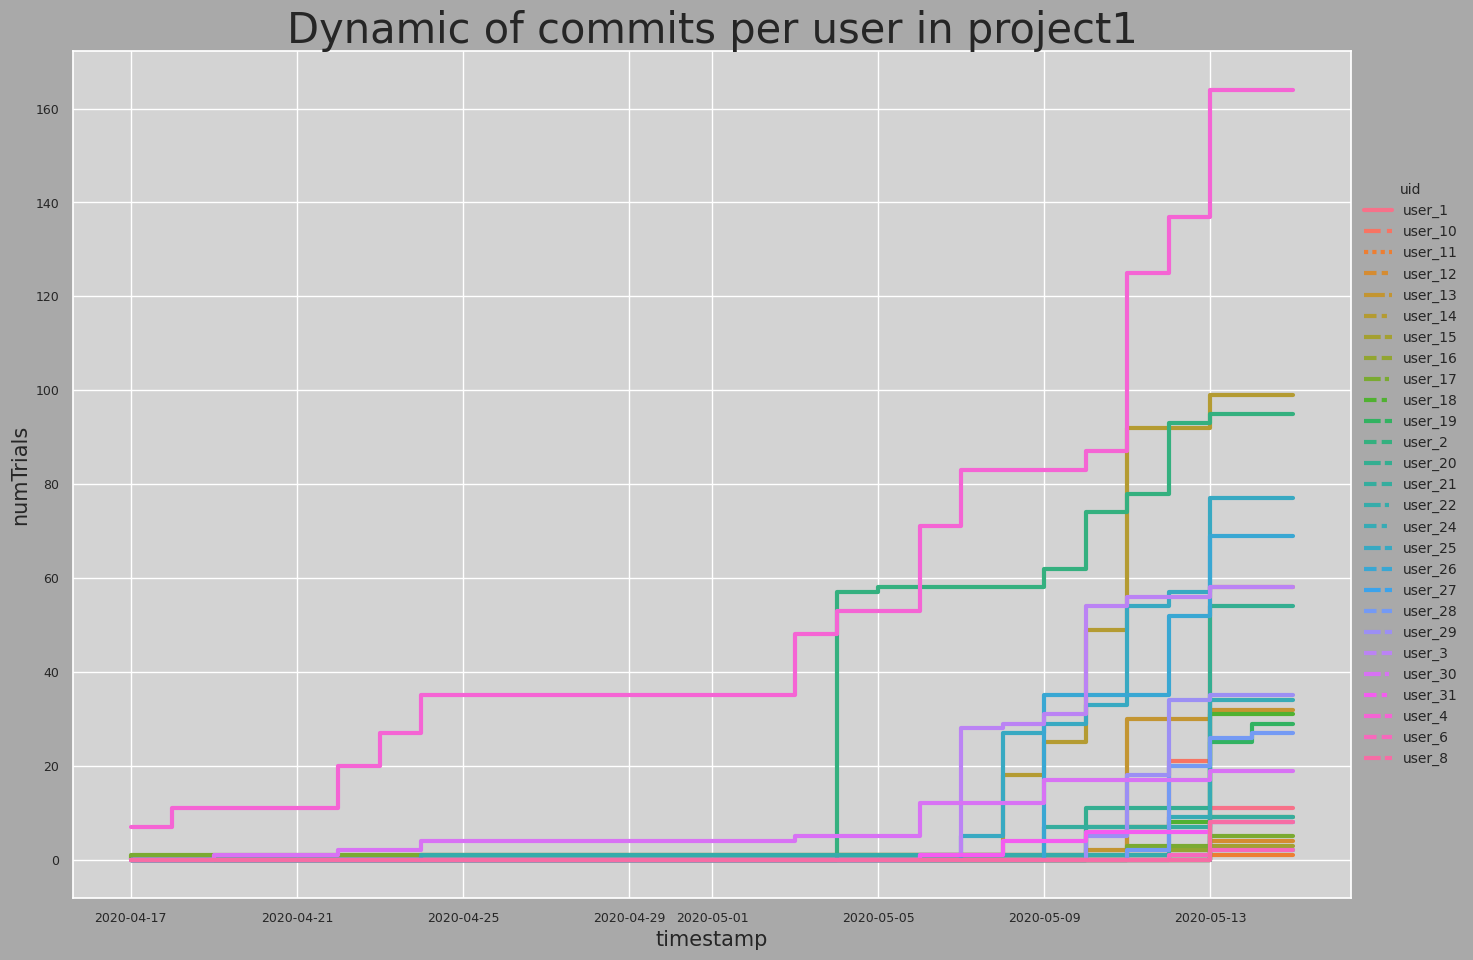

In [2]:
sns.set_theme(rc={'figure.figsize':(15*1.1, 10*1.1), 'figure.facecolor': 'darkgrey', 'axes.facecolor': 'lightgrey'})
sns.color_palette("blend:#7AB,#EDA", as_cmap=True)

fig , ax = plt.subplots()
ax.set_yticks(range(0, 180, 20), labels=range(0, 180, 20))
sns.lineplot(data=commits, linewidth=3)
ax = plt.gca()
ax.set_title("Dynamic of commits per user in project1", fontsize=30)
ax.set_xlabel("timestamp",fontsize=15)
ax.set_ylabel("numTrials",fontsize=15)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False, title='uid', title_fontproperties={'size': 10})
ax.tick_params(labelsize=9)

for line in ax.lines:
    line.set_drawstyle('steps-pre')
    line.set_linestyle('-')
    
plt.show()

In [3]:
connection.close()

1. Q: Which user was the leader in the number of commits almost all of the time?  
A: user_4.
   
3. Q: Which user was the leader for only a short period of time?  
A: The answer: user_2.